# Homework for Lab 3.5

In [2]:
import torch
import numpy as np

device = 'cpu'
torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
  device = 'cuda'
  torch.cuda.manual_seed(42)
  torch.cuda.manual_seed_all(42)
  torch.backends.cuda.matmul.allow_tf32 = True
  torch.backends.cudnn.allow_tf32 = True
  torch.cuda.empty_cache()

print(f"Using device: {device}")

Using device: cuda


## Using HF Datasets

In [3]:
from datasets import load_dataset

ag_news_dataset = load_dataset("SetFit/ag_news")

temp = ag_news_dataset["train"].train_test_split(test_size=0.2)
ag_news_dataset['val'] = temp['test']
ag_news_dataset['train'] = temp['train']

## 3.5.1 To laugh or not to laugh

In [4]:
url = "https://raw.githubusercontent.com/Fraser-Greenlee/my-huggingface-datasets/master/data/short-jokes/train.txt"

jokes_dataset = load_dataset(
    "text",
    data_files={"train": url}
)


In [5]:
import re

def clean(example):
    text = example["text"]
    text = text.lower()
    text = re.sub(r"[\x08\x10#$%&+/\\~{|}\^]", "", text)
    return {"text": text}

print("before adjusting: ",jokes_dataset["train"][15])

jokes_dataset = jokes_dataset.map(clean)

print("after adjusting: ",jokes_dataset["train"][15])


before adjusting:  {'text': 'You ever notice that the most dangerous thing about marijuana is getting caught with it?'}
after adjusting:  {'text': 'you ever notice that the most dangerous thing about marijuana is getting caught with it?'}


#### Mapping

In [6]:
import torch
import numpy as np

char_set = sorted(set("".join(jokes_dataset["train"]["text"])))

# add padding token
char_set.append("^")

VOC_SIZE = len(char_set)

# create a mapping from characters to integers and vice versa
char2int = {ch: i for i, ch in enumerate(char_set)}
int2char = {i: ch for i, ch in enumerate(char_set)}

jokes_list = jokes_dataset["train"]["text"]
filtered_jokes = [joke for joke in jokes_list if len(joke) >= 130]
encoded_jokes = [
    torch.tensor([char2int[ch] for ch in joke], dtype=torch.long)
    for joke in filtered_jokes
]

# example
print(filtered_jokes[0])
print(encoded_jokes[0])
print("Character to Integer mapping: ", char2int)
print("\nInteger to Character mapping: ", int2char)


what's the difference between an illegal mexican and an autonomous robot...? nothing... they were both made to steal american jobs.
tensor([53, 38, 31, 50,  3, 49,  0, 50, 38, 35,  0, 34, 39, 36, 36, 35, 48, 35,
        44, 33, 35,  0, 32, 35, 50, 53, 35, 35, 44,  0, 31, 44,  0, 39, 42, 42,
        35, 37, 31, 42,  0, 43, 35, 54, 39, 33, 31, 44,  0, 31, 44, 34,  0, 31,
        44,  0, 31, 51, 50, 45, 44, 45, 43, 45, 51, 49,  0, 48, 45, 32, 45, 50,
         9,  9,  9, 25,  0, 44, 45, 50, 38, 39, 44, 37,  9,  9,  9,  0, 50, 38,
        35, 55,  0, 53, 35, 48, 35,  0, 32, 45, 50, 38,  0, 43, 31, 34, 35,  0,
        50, 45,  0, 49, 50, 35, 31, 42,  0, 31, 43, 35, 48, 39, 33, 31, 44,  0,
        40, 45, 32, 49,  9])
Character to Integer mapping:  {' ': 0, '!': 1, '"': 2, "'": 3, '(': 4, ')': 5, '*': 6, ',': 7, '-': 8, '.': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14, '5': 15, '6': 16, '7': 17, '8': 18, '9': 19, ':': 20, ';': 21, '<': 22, '=': 23, '>': 24, '?': 25, '@': 26, '[': 27, ']': 

In [ ]:
from torch.nn.utils.rnn import pad_sequence

max_length = max(len(j) for j in encoded_jokes)
print(max_length)
pad = char2int["^"]

# padding
padded_jokes = pad_sequence(
    encoded_jokes,
    batch_first=True,
    padding_value=pad
)

print(padded_jokes.shape)
print("example: ", padded_jokes[3])

213
torch.Size([43575, 213])
example:  tensor([53, 39, 50, 38,  0, 36, 31, 33, 35, 32, 45, 45, 41,  7,  0, 55, 45, 51,
         0, 33, 31, 44,  0, 49, 50, 31, 55,  0, 39, 44,  0, 50, 45, 51, 33, 38,
         0, 53, 39, 50, 38,  0, 46, 35, 45, 46, 42, 35,  0, 55, 45, 51,  0, 53,
        45, 51, 42, 34,  0, 45, 50, 38, 35, 48, 53, 39, 49, 35,  0, 44, 35, 52,
        35, 48,  0, 50, 31, 42, 41,  0, 50, 45,  7,  0, 32, 51, 50,  0, 50, 38,
        31, 50,  3, 49,  0, 45, 44, 42, 55,  0, 45, 44, 35,  0, 45, 36,  0, 50,
        38, 35,  0, 43, 31, 44, 55,  0, 31, 53, 36, 51, 42,  0, 50, 38, 39, 44,
        37, 49,  0, 31, 32, 45, 51, 50,  0, 39, 50, 57, 57, 57, 57, 57, 57, 57,
        57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57,
        57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57,
        57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57,
        57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57])


#### Datasets and Dataloader

We use a function creating a **many-to-many** sequence

Dataset : 
Here one sequence is on joke and we create the input and output sequence by shifting it by one position.

In [8]:
from torch.utils.data import TensorDataset, DataLoader

class JokesDataset(TensorDataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

def create_many_to_many_sequences(data):
    inputs  = data[:, :-1]
    targets = data[:, 1:]
    return inputs, targets

input_seq, output_seq = create_many_to_many_sequences(padded_jokes)
jokesDataset = JokesDataset(input_seq, output_seq)


/tmp/ipykernel_33833/190758527.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.long)
/tmp/ipykernel_33833/190758527.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


Dataloader :

In [9]:
BATCH_SIZE = 256
jokes_dataloader = DataLoader(jokesDataset, BATCH_SIZE, shuffle=True)

print(next(iter(jokes_dataloader)))

# example
example_input, example_target = jokesDataset[0]

print("Input indices:")
print(example_input)

print("\nTarget indices:")
print(example_target)

input_text = "".join(int2char[idx.item()] for idx in example_input)
target_text = "".join(int2char[idx.item()] for idx in example_target)

print("Input text:")
print(input_text)

print("\nTarget text:")
print(target_text)


[tensor([[53, 38, 31,  ..., 57, 57, 57],
        [39,  3, 52,  ..., 57, 57, 57],
        [34, 45, 37,  ..., 57, 57, 57],
        ...,
        [43, 55,  0,  ..., 57, 57, 57],
        [31,  0, 43,  ..., 57, 57, 57],
        [53, 38, 31,  ..., 57, 57, 57]]), tensor([[38, 31, 50,  ..., 57, 57, 57],
        [ 3, 52, 35,  ..., 57, 57, 57],
        [45, 37, 49,  ..., 57, 57, 57],
        ...,
        [55,  0, 33,  ..., 57, 57, 57],
        [ 0, 43, 31,  ..., 57, 57, 57],
        [38, 31, 50,  ..., 57, 57, 57]])]
Input indices:
tensor([53, 38, 31, 50,  3, 49,  0, 50, 38, 35,  0, 34, 39, 36, 36, 35, 48, 35,
        44, 33, 35,  0, 32, 35, 50, 53, 35, 35, 44,  0, 31, 44,  0, 39, 42, 42,
        35, 37, 31, 42,  0, 43, 35, 54, 39, 33, 31, 44,  0, 31, 44, 34,  0, 31,
        44,  0, 31, 51, 50, 45, 44, 45, 43, 45, 51, 49,  0, 48, 45, 32, 45, 50,
         9,  9,  9, 25,  0, 44, 45, 50, 38, 39, 44, 37,  9,  9,  9,  0, 50, 38,
        35, 55,  0, 53, 35, 48, 35,  0, 32, 45, 50, 38,  0, 43, 31, 34, 35

#### Model

In [10]:
import torch.nn as nn

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size, num_layers=1, drop_rate=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size) # 58 x 16, matrix: one line/caracter + colonne/feature learnt
        self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_rate)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        x = self.embedding(x)
        if state is None:
            x, hstate = self.lstm(x)
        else:
            x, hstate = self.lstm(x, state)
        x = self.dropout(x)
        logits = self.output(x)
        return logits, hstate


In [11]:
# initialize model
hidden_size = 64
embedding_size = 16

model = CharRNN(VOC_SIZE, embedding_size, hidden_size, num_layers=2).to(device)
print(model)

CharRNN(
  (embedding): Embedding(58, 16)
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=64, out_features=58, bias=True)
)


Training:

In [12]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def train_model(model, optimizer, loss_fn, dataloader, num_epochs=10):

    model.train()
    history = {'train_loss': []}
    for epoch in range(num_epochs):

        epoch_loss = 0.0
        for data, targets in tqdm(dataloader):

            # Forward pass
            data = data.to(device).long()
            targets = targets.to(device).long()
            logits, _ = model(data)

            # Adjust dimensions
            running_loss = loss_fn(
                logits.view(-1, VOC_SIZE),
                targets.view(-1)
            )

            # Backward pass
            optimizer.zero_grad()
            running_loss.backward()
            optimizer.step()

            # Cumulate loss
            epoch_loss += running_loss.item()

        mean_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(mean_loss)

        print(f"Epoch {epoch + 1}/{num_epochs}", f"| Train Loss: {mean_loss}:", sep=" ")


    return history


def plot_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()


  0%|          | 0/171 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.116832863517672:


  0%|          | 0/171 [00:00<?, ?it/s]

Epoch 2/10 | Train Loss: 1.602083272404141:


  0%|          | 0/171 [00:00<?, ?it/s]

...

Epoch 8/10 | Train Loss: 1.235431650925798:


  0%|          | 0/171 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 1.2195302749934949:


  0%|          | 0/171 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.2066187816753722:


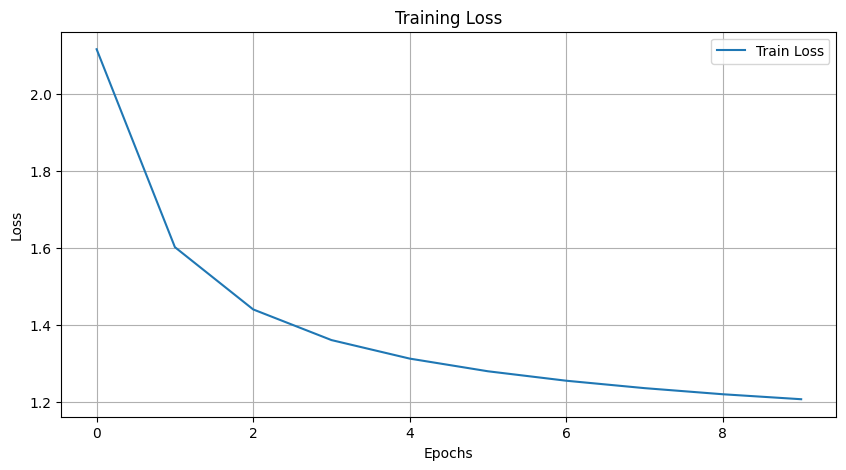

In [13]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

history = train_model(model, optimizer, loss_fn, jokes_dataloader, num_epochs=10)
plot_loss(history)

execution time: 18.3s

#### Generating

In [15]:
import torch.nn.functional as F
from torch.distributions.categorical import Categorical

def generate_text(model, start_text, length=200, scaling_factor=1.):
    model.eval()
    # Encode the start_text to integer indices
    input_seq = torch.tensor(
        [char2int[c] for c in start_text],
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    hidden = None
    result = start_text
    for _ in range(length):
        with torch.no_grad():
            output, hidden = model(input_seq, hidden)
            output = output[:, -1, :]
            output = output * scaling_factor
            char_id = Categorical(logits=output).sample().item()
            result += int2char[char_id]
            input_seq = torch.tensor([[char_id]], dtype=torch.long, device=device)

    return result

generated_text = generate_text(model, start_text="a data scientist walks into a bar", scaling_factor=1)
print(generated_text)


a data scientist walks into a bar nonat arred."" they siss on you'll him-a how (a bad, and in the winch on: stuild. hi sle! repath-m) so about every last ragic, ence friend gonna on forwery lave uble with cest-times some wife? i'nlin


## 3.5.2 News Article Generation by Character-Level RNN

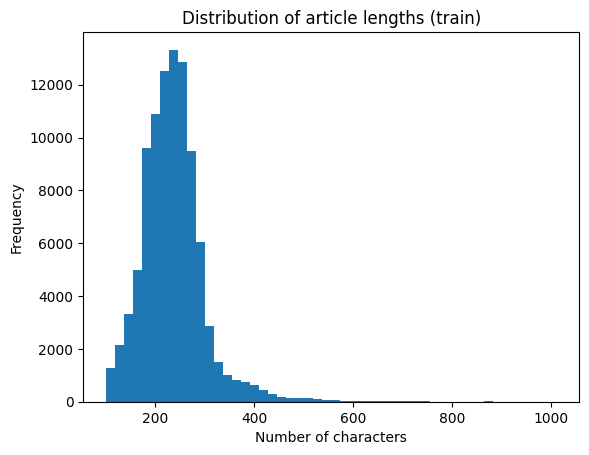

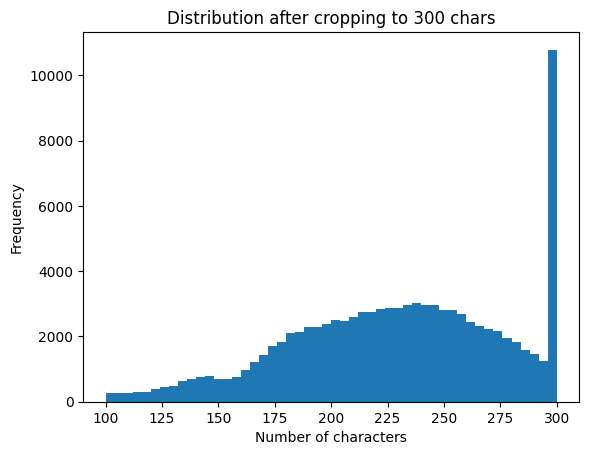

In [16]:
from datasets import load_dataset
import matplotlib.pyplot as plt


lengths = [len(article) for article in ag_news_dataset["train"]["text"]]

# visualization
train_texts = [t[:300] for t in ag_news_dataset["train"]["text"]]
val_texts = [t[:300] for t in ag_news_dataset["val"]["text"]]

# before cropping
plt.hist(lengths, bins=50)
plt.title("Distribution of article lengths (train)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

cropped_lengths = [len(t) for t in train_texts]

# after cropping
plt.hist(cropped_lengths, bins=50)
plt.title("Distribution after cropping to 300 chars")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

##### Dataset

In [17]:
import torch
import numpy as np

char_set = sorted(set("".join(train_texts)))

# add padding token
char_set.append("^")

VOC_SIZE = len(char_set)
print(f"vocabulary size : ", VOC_SIZE)

# create a mapping from characters to integers and inverse
char2int = {ch: i for i, ch in enumerate(char_set)}
int2char = {i: ch for i, ch in enumerate(char_set)}

# training datas
filtered_news = [news for news in train_texts if len(news) >= 130]
encoded_news = [
    torch.tensor([char2int[ch] for ch in news], dtype=torch.long)
    for news in filtered_news
]

# val datas
filtered_news_val = [news for news in val_texts if len(news) >= 130]
encoded_news_val = [
    torch.tensor([char2int[ch] for ch in news], dtype=torch.long)
    for news in filtered_news
]

# example
print(filtered_news[0])
print(encoded_news[0])
print("Character to Integer mapping: ", char2int)
print("\nInteger to Character mapping: ", int2char)

vocabulary size :  83
Nation #39;s Cotton Crop May Exceed Records This year #39;s cotton crop is on pace to be the largest in US history, although hurricanes that have battered the nation in the past few months may reduce the final amount.
tensor([41, 56, 75, 64, 70, 69,  0,  3, 17, 23, 25, 74,  0, 30, 70, 75, 75, 70,
        69,  0, 30, 73, 70, 71,  0, 40, 56, 80,  0, 32, 79, 58, 60, 60, 59,  0,
        45, 60, 58, 70, 73, 59, 74,  0, 47, 63, 64, 74,  0, 80, 60, 56, 73,  0,
         3, 17, 23, 25, 74,  0, 58, 70, 75, 75, 70, 69,  0, 58, 73, 70, 71,  0,
        64, 74,  0, 70, 69,  0, 71, 56, 58, 60,  0, 75, 70,  0, 57, 60,  0, 75,
        63, 60,  0, 67, 56, 73, 62, 60, 74, 75,  0, 64, 69,  0, 48, 46,  0, 63,
        64, 74, 75, 70, 73, 80, 10,  0, 56, 67, 75, 63, 70, 76, 62, 63,  0, 63,
        76, 73, 73, 64, 58, 56, 69, 60, 74,  0, 75, 63, 56, 75,  0, 63, 56, 77,
        60,  0, 57, 56, 75, 75, 60, 73, 60, 59,  0, 75, 63, 60,  0, 69, 56, 75,
        64, 70, 69,  0, 64, 69,  0, 75, 

In [18]:
# padding

from torch.nn.utils.rnn import pad_sequence

max_length = 300
pad = char2int["^"]

# padding
padded_news = pad_sequence(
    encoded_news,
    batch_first=True,
    padding_value=pad
)
padded_news_val = pad_sequence(
    encoded_news_val,
    batch_first=True,
    padding_value=pad
)

print(padded_news.shape)
print("example: ", padded_news[3])

torch.Size([93575, 300])
example:  tensor([46, 64, 73, 64, 76, 74,  0, 46, 56, 75, 60, 67, 67, 64, 75, 60,  0, 46,
        64, 62, 69, 74,  0, 35, 70, 78, 56, 73, 59,  0, 46, 75, 60, 73, 69,  0,
        75, 70,  0, 19, 11, 52, 60, 56, 73,  0, 28, 58, 58, 70, 73, 59,  0,  7,
        48, 71, 59, 56, 75, 60, 23,  8,  0, 35, 70, 78, 56, 73, 59,  0, 46, 75,
        60, 73, 69, 10,  0, 63, 70, 74, 75,  0, 70, 61,  0, 75, 63, 60,  0, 75,
        70, 71, 11, 73, 56, 75, 60, 59,  0, 73, 56, 59, 64, 70,  0, 74, 63, 70,
        78,  0, 61, 70, 73,  0, 80, 70, 76, 69, 62,  0, 68, 60, 69,  0, 64, 69,
         0, 41, 60, 78,  0, 52, 70, 73, 66,  0, 56, 69, 59,  0, 39, 70, 74,  0,
        28, 69, 62, 60, 67, 60, 74, 10,  0, 78, 64, 67, 67,  0, 68, 70, 77, 60,
         0, 75, 70,  0, 46, 64, 73, 64, 76, 74,  0, 46, 56, 75, 60, 67, 67, 64,
        75, 60,  0, 45, 56, 59, 64, 70,  0, 36, 69, 58, 12, 82, 82, 82, 82, 82,
        82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82,
     

In [19]:
from torch.utils.data import TensorDataset, DataLoader

class NewsDataset(TensorDataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# training dataset
input_seq, output_seq = create_many_to_many_sequences(padded_news)
news_dataset = NewsDataset(input_seq, output_seq)

# validating dataset
input_seq, output_seq = create_many_to_many_sequences(padded_news_val)
news_dataset_val = NewsDataset(input_seq, output_seq)

/tmp/ipykernel_30654/2379090749.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.long)
/tmp/ipykernel_30654/2379090749.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


### Computing input and output sequences

In [20]:
news_dataloader = DataLoader(news_dataset, BATCH_SIZE, shuffle=True)
news_dataloader_val = DataLoader(news_dataset_val, BATCH_SIZE, shuffle=True)

print(next(iter(news_dataloader)))

# example
example_input, example_target = news_dataset[0]

print("Input indices:")
print(example_input)

print("\nTarget indices:")
print(example_target)

input_text = "".join(int2char[idx.item()] for idx in example_input)
target_text = "".join(int2char[idx.item()] for idx in example_target)

print("Input text:")
print(input_text)

print("\nTarget text:")
print(target_text)


[tensor([[38, 36, 41,  ..., 82, 82, 82],
        [30, 56, 69,  ..., 82, 82, 82],
        [46, 64, 69,  ..., 82, 82, 82],
        ...,
        [37, 70, 63,  ..., 82, 82, 82],
        [35, 56, 67,  ..., 82, 82, 82],
        [38, 60, 69,  ..., 82, 82, 82]]), tensor([[36, 41, 34,  ..., 82, 82, 82],
        [56, 69, 56,  ..., 82, 82, 82],
        [64, 69, 62,  ..., 82, 82, 82],
        ...,
        [70, 63, 56,  ..., 82, 82, 82],
        [56, 67, 70,  ..., 82, 82, 82],
        [60, 69, 80,  ..., 82, 82, 82]])]
Input indices:
tensor([41, 56, 75, 64, 70, 69,  0,  3, 17, 23, 25, 74,  0, 30, 70, 75, 75, 70,
        69,  0, 30, 73, 70, 71,  0, 40, 56, 80,  0, 32, 79, 58, 60, 60, 59,  0,
        45, 60, 58, 70, 73, 59, 74,  0, 47, 63, 64, 74,  0, 80, 60, 56, 73,  0,
         3, 17, 23, 25, 74,  0, 58, 70, 75, 75, 70, 69,  0, 58, 73, 70, 71,  0,
        64, 74,  0, 70, 69,  0, 71, 56, 58, 60,  0, 75, 70,  0, 57, 60,  0, 75,
        63, 60,  0, 67, 56, 73, 62, 60, 74, 75,  0, 64, 69,  0, 48, 46,  0

#### Model

In [21]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers=1, drop_rate=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.lstm = nn.LSTM(vocab_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_rate)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        x = F.one_hot(x, num_classes=self.vocab_size).float()
        out, hstate = self.lstm(x, state) if state is not None else self.lstm(x)
        out = self.dropout(out)
        logits = self.output(out)
        return logits, hstate

In [22]:
hidden_size = 256

model = CharRNN(VOC_SIZE, hidden_size, num_layers=2).to(device)
print(model)

CharRNN(
  (lstm): LSTM(83, 256, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=256, out_features=83, bias=True)
)


#### Training

In [24]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def train_model(model, optimizer, loss_fn, dataloader, num_epochs=10):

    model.train()
    history = {'train_loss': []}
    for epoch in range(num_epochs):

        epoch_loss = 0.0
        for data, targets in tqdm(dataloader):

            # Forward pass
            data = data.to(device).long()
            targets = targets.to(device).long()
            logits, _ = model(data)

            # Adjust dimensions
            running_loss = loss_fn(
                logits.view(-1, VOC_SIZE),
                targets.view(-1)
            )

            # Backward pass
            optimizer.zero_grad()
            running_loss.backward()
            optimizer.step()

            # Cumulate loss
            epoch_loss += running_loss.item()

        mean_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(mean_loss)

        print(f"Epoch {epoch + 1}/{num_epochs}", f"| Train Loss: {mean_loss}:", sep=" ")

    return history


def plot_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()


  0%|          | 0/366 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 2.4908003194736:


  0%|          | 0/366 [00:00<?, ?it/s]

Epoch 2/10 | Train Loss: 1.6732935869628613:


  0%|          | 0/366 [00:00<?, ?it/s]

...

Epoch 8/10 | Train Loss: 1.0667339608968933:


  0%|          | 0/366 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 1.0429030695899588:


  0%|          | 0/366 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.0234159138359007:


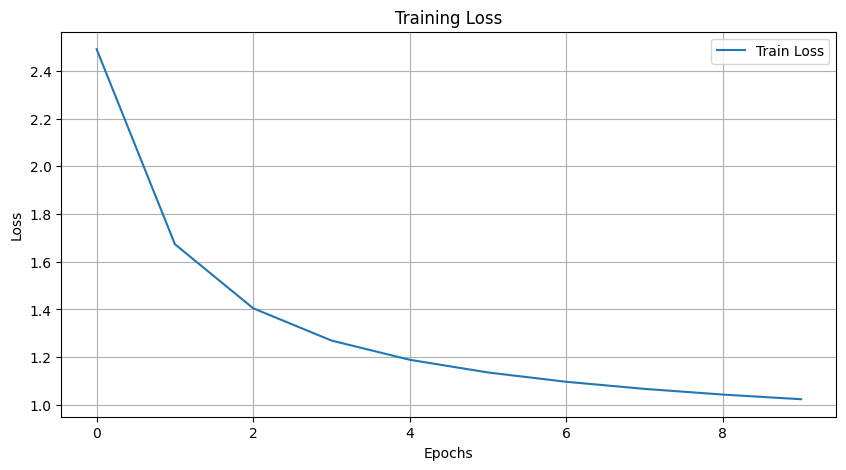

In [25]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

history = train_model(model, optimizer, loss_fn, news_dataloader, num_epochs=10)
plot_loss(history)

#### Evaluating Many-to-many problem

In [ ]:
model.eval()
test_loss = 0.0

with torch.no_grad():
    for sample_x, sample_y in news_dataloader_val:

        sample_x = sample_x.to(device)
        sample_y = sample_y.to(device)

        preds, _ = model(sample_x)

        loss = loss_fn(
            preds.reshape(-1, VOC_SIZE),
            sample_y.reshape(-1)
        )

        test_loss += loss.item()
    
    sample_x, sample_y = next(iter(news_dataloader_val))
    sample_x = sample_x[0:1].to(device)
    pred, _ = model(sample_x)
    prediction = pred.cpu().numpy().squeeze()
    actual = sample_y[0].cpu().numpy().squeeze()

test_loss /= len(news_dataloader_val)

print(f"Cross entropy loss: {test_loss:.4f}")

Cross entropy loss: 0.9929


#### Generating example texts

In [ ]:
import torch
from torch.distributions.categorical import Categorical

def generate_text(model, start_text, length=200, scaling_factor=1.0):

    model.eval()

    input_seq = torch.tensor(
        [char2int[c] for c in start_text],
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    result = start_text

    hidden = None
    with torch.no_grad():
        for _ in range(length):

            output, hidden = model(input_seq, hidden)
            output = output[:, -1, :]
            output = output * scaling_factor 

            char_id = Categorical(logits=output).sample().item() # take one random caracter from resulting probability 

            result += int2char[char_id]

            input_seq = torch.tensor(
                [[char_id]],
                dtype=torch.long,
                device=device
            )
    return result

generated_text = generate_text(model, start_text="The", scaling_factor=1)
print(generated_text)

The foil start of Sol 3ver count begins for Arsenal Corporation flood breaches on the United States  reveal Development County to the media the regor effort to Johnson were charged ill doctors breed to a


## 3.5.3 News Article Classification by Character-Level RNN

#### Pre-process

In [94]:
from datasets import load_dataset
import matplotlib.pyplot as plt


lengths_text = [len(article) for article in ag_news_dataset["train"]["text"]]

# visualization
train_texts = [t[:300] for t in ag_news_dataset["train"]["text"]]
train_class = ag_news_dataset["train"]["label"]


val_texts = [t[:300] for t in ag_news_dataset["val"]["text"]]
val_class = ag_news_dataset["val"]["label"]

In [135]:
import torch
import numpy as np

char_set = sorted(set("".join(train_texts)))

# add padding token
char_set.append("^")

VOC_SIZE = len(char_set)
print(f"vocabulary size : ", VOC_SIZE)

# create a mapping from characters to integers and vice versa
char2int = {ch: i for i, ch in enumerate(char_set)}
int2char = {i: ch for i, ch in enumerate(char_set)}

# training datas
filtered_news = [news for news in train_texts if len(news) >= 130]
encoded_news = [
    torch.tensor([char2int[ch] for ch in news], dtype=torch.long)
    for news in filtered_news
]

# val datas
filtered_news_val = [news for news in val_texts if len(news) >= 130]
encoded_news_val = [
    torch.tensor([char2int[ch] for ch in news], dtype=torch.long)
    for news in filtered_news_val
]

# example
print(filtered_news[0])
print(encoded_news[0])
print("Character to Integer mapping: ", char2int)
print("\nInteger to Character mapping: ", int2char)

vocabulary size :  83
Nation #39;s Cotton Crop May Exceed Records This year #39;s cotton crop is on pace to be the largest in US history, although hurricanes that have battered the nation in the past few months may reduce the final amount.
tensor([41, 56, 75, 64, 70, 69,  0,  3, 17, 23, 25, 74,  0, 30, 70, 75, 75, 70,
        69,  0, 30, 73, 70, 71,  0, 40, 56, 80,  0, 32, 79, 58, 60, 60, 59,  0,
        45, 60, 58, 70, 73, 59, 74,  0, 47, 63, 64, 74,  0, 80, 60, 56, 73,  0,
         3, 17, 23, 25, 74,  0, 58, 70, 75, 75, 70, 69,  0, 58, 73, 70, 71,  0,
        64, 74,  0, 70, 69,  0, 71, 56, 58, 60,  0, 75, 70,  0, 57, 60,  0, 75,
        63, 60,  0, 67, 56, 73, 62, 60, 74, 75,  0, 64, 69,  0, 48, 46,  0, 63,
        64, 74, 75, 70, 73, 80, 10,  0, 56, 67, 75, 63, 70, 76, 62, 63,  0, 63,
        76, 73, 73, 64, 58, 56, 69, 60, 74,  0, 75, 63, 56, 75,  0, 63, 56, 77,
        60,  0, 57, 56, 75, 75, 60, 73, 60, 59,  0, 75, 63, 60,  0, 69, 56, 75,
        64, 70, 69,  0, 64, 69,  0, 75, 

In [136]:
# padding

from torch.nn.utils.rnn import pad_sequence

max_length = 300
pad = char2int["^"]

# padding
padded_news = pad_sequence(
    encoded_news,
    batch_first=True,
    padding_value=pad
)
padded_news_val = pad_sequence(
    encoded_news_val,
    batch_first=True,
    padding_value=pad
)

print(padded_news.shape)
print("example: ", padded_news[3])

torch.Size([93575, 300])
example:  tensor([46, 64, 73, 64, 76, 74,  0, 46, 56, 75, 60, 67, 67, 64, 75, 60,  0, 46,
        64, 62, 69, 74,  0, 35, 70, 78, 56, 73, 59,  0, 46, 75, 60, 73, 69,  0,
        75, 70,  0, 19, 11, 52, 60, 56, 73,  0, 28, 58, 58, 70, 73, 59,  0,  7,
        48, 71, 59, 56, 75, 60, 23,  8,  0, 35, 70, 78, 56, 73, 59,  0, 46, 75,
        60, 73, 69, 10,  0, 63, 70, 74, 75,  0, 70, 61,  0, 75, 63, 60,  0, 75,
        70, 71, 11, 73, 56, 75, 60, 59,  0, 73, 56, 59, 64, 70,  0, 74, 63, 70,
        78,  0, 61, 70, 73,  0, 80, 70, 76, 69, 62,  0, 68, 60, 69,  0, 64, 69,
         0, 41, 60, 78,  0, 52, 70, 73, 66,  0, 56, 69, 59,  0, 39, 70, 74,  0,
        28, 69, 62, 60, 67, 60, 74, 10,  0, 78, 64, 67, 67,  0, 68, 70, 77, 60,
         0, 75, 70,  0, 46, 64, 73, 64, 76, 74,  0, 46, 56, 75, 60, 67, 67, 64,
        75, 60,  0, 45, 56, 59, 64, 70,  0, 36, 69, 58, 12, 82, 82, 82, 82, 82,
        82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82,
     

In [137]:
from torch.utils.data import TensorDataset, DataLoader

class NewsDataset(TensorDataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# training dataset
news_dataset = NewsDataset(padded_news, train_class)

# validating dataset
news_dataset_val = NewsDataset(padded_news_val, val_class)

/tmp/ipykernel_3341/4048582498.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.long)


In [138]:
BATCH_SIZE = 512

news_dataloader = DataLoader(news_dataset, BATCH_SIZE, shuffle=True)
news_dataloader_val = DataLoader(news_dataset_val, BATCH_SIZE, shuffle=True)

print(next(iter(news_dataloader)))

# example
example_input, example_target = news_dataset[50]

print("Input indices:")
print(example_input)

print("\nInput text:")
input_text = "".join(int2char[idx.item()] for idx in example_input)
print(input_text)

print("\nTarget class index:")
print(example_target.item())


[tensor([[39, 56, 78,  ..., 82, 82, 82],
        [34, 56, 68,  ...,  0, 67, 60],
        [28, 40, 31,  ..., 56, 73, 67],
        ...,
        [40, 56, 76,  ..., 82, 82, 82],
        [28, 68, 60,  ..., 82, 82, 82],
        [43, 67, 56,  ..., 82, 82, 82]]), tensor([0, 2, 1, 2, 0, 0, 2, 0, 2, 3, 1, 2, 1, 0, 1, 0, 0, 2, 3, 3, 3, 0, 0, 3,
        2, 3, 1, 3, 3, 1, 0, 0, 1, 1, 1, 2, 3, 3, 3, 1, 1, 1, 0, 3, 0, 1, 1, 1,
        2, 0, 1, 2, 3, 3, 3, 3, 1, 0, 3, 2, 0, 2, 3, 0, 3, 0, 3, 3, 2, 3, 2, 0,
        2, 2, 3, 0, 3, 3, 0, 1, 3, 0, 3, 3, 0, 0, 1, 2, 0, 2, 0, 0, 0, 2, 0, 0,
        2, 0, 1, 0, 1, 3, 0, 0, 0, 0, 0, 2, 2, 1, 2, 1, 1, 2, 2, 0, 0, 2, 2, 3,
        1, 0, 0, 2, 1, 1, 1, 2, 3, 2, 0, 1, 1, 0, 1, 3, 1, 0, 0, 0, 1, 2, 2, 2,
        1, 3, 2, 2, 2, 1, 3, 2, 2, 1, 2, 1, 0, 3, 0, 0, 2, 1, 1, 3, 3, 0, 2, 2,
        3, 3, 0, 2, 0, 1, 2, 2, 2, 0, 1, 1, 3, 3, 1, 1, 0, 0, 3, 1, 1, 2, 2, 0,
        0, 3, 2, 0, 2, 2, 3, 2, 0, 2, 2, 0, 0, 3, 2, 1, 1, 0, 1, 3, 3, 2, 0, 0,
        3, 1, 0, 0, 1, 0

#### Model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers=1, drop_rate=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.lstm = nn.LSTM(vocab_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_rate)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):

        x = F.one_hot(x, num_classes=self.vocab_size).float()

        _, (hidden, _) = self.lstm(x)

        last_hidden = hidden[-1]

        logits = self.output(last_hidden)

        return logits

In [113]:
hidden_size = 32

model = CharRNN(VOC_SIZE, hidden_size, num_layers=5).to(device)
print(model)

CharRNN(
  (lstm): LSTM(83, 32, num_layers=5, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=32, out_features=83, bias=True)
)


#### Training

In [ ]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def train_classifier(model, optimizer, loss_fn, dataloader, num_epochs=5, device='cpu'):

    model.to(device)
    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(num_epochs):

        model.train()

        epoch_loss = 0.0
        correct = 0
        total = 0

        for data, targets in tqdm(dataloader, desc=f"Epoch {epoch+1}"):

            data = data.to(device).long()
            targets = targets.to(device).long()

            logits = model(data)
            loss = loss_fn(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Loss
            epoch_loss += loss.item() * data.size(0)

            # Accuracy
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        epoch_loss = epoch_loss / len(dataloader.dataset)
        epoch_acc = correct / total

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    return history





In [130]:
def plot_loss(history):
    plt.figure(figsize=(10, 5))

    plt.plot(history['train_loss'])
    plt.title("Train Loss")
    plt.xlabel("Epoch")


    plt.show()

In [127]:

model.to(device)
data, targets = next(iter(news_dataloader))

data = data.to(device).long()
targets = targets.to(device).long()

logits = model(data)

print("Input shape:", data.shape)
print("Logits shape:", logits.shape)
print("Target shape:", targets.shape)

Input shape: torch.Size([512, 300])
Logits shape: torch.Size([512, 83])
Target shape: torch.Size([512])


In [ ]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

history = train_classifier(model, optimizer, loss_fn, news_dataloader, num_epochs=10)


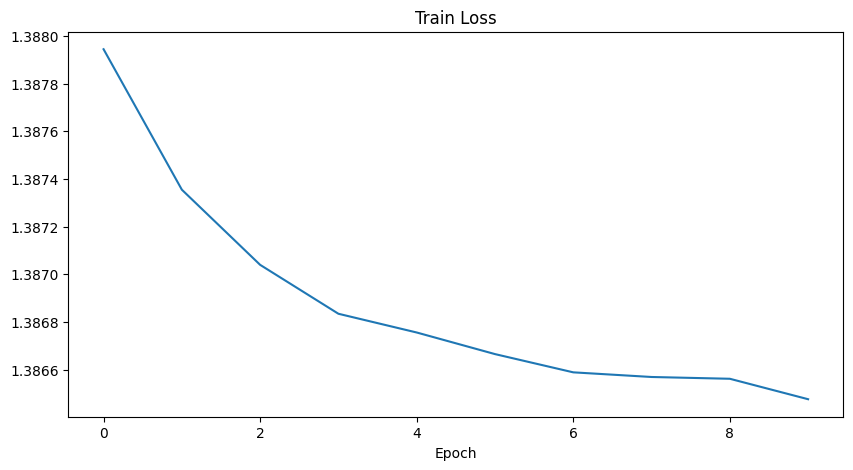

In [131]:
plot_loss(history)

Epoch 1/10 | Loss: 1.3879 | Acc: 0.2484
Epoch 2/10 | Loss: 1.3874 | Acc: 0.2498
Epoch 3/10 | Loss: 1.3870 | Acc: 0.2474
Epoch 4/10 | Loss: 1.3868 | Acc: 0.2497
Epoch 5/10 | Loss: 1.3868 | Acc: 0.2484
Epoch 6/10 | Loss: 1.3867 | Acc: 0.2497
Epoch 7/10 | Loss: 1.3866 | Acc: 0.2496
Epoch 8/10 | Loss: 1.3866 | Acc: 0.2485
Epoch 9/10 | Loss: 1.3866 | Acc: 0.2478


In [129]:
print(np.mean(history["train_acc"]))

0.24906545551696505


#### Eval

In [140]:
model.eval()
model.to(device)

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for sample_x, sample_y in news_dataloader_val:

        sample_x = sample_x.to(device).long()
        sample_y = sample_y.to(device).long()

        logits = model(sample_x) 

        # Loss
        loss = loss_fn(logits, sample_y)

        test_loss += loss.item() * sample_x.size(0)

        # Accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == sample_y).sum().item()
        total += sample_y.size(0)

test_loss /= len(news_dataloader_val.dataset)
test_acc = correct / total

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 1.3866
Test accuracy: 0.2470


Test accuracy: 0.2470
(below train accuracy)